# Notebook demo - Blood Cell Classification

Hướng đúng của project: **Recognition (Classification)** là chính.
`dataset2-master` dùng để train WBC classifier. `dataset-master` chỉ dùng để demo ảnh kính hiển vi, WBC proposal/crop và RBC detector hỗ trợ.


## 1. Import và setup path


In [1]:
import sys
import random
from pathlib import Path
from collections import Counter
import xml.etree.ElementTree as ET

import cv2
import matplotlib.pyplot as plt
import torch
from torchvision import datasets

ROOT = Path.cwd()
for parent in [ROOT] + list(ROOT.parents):
    if (parent / "src").exists():
        PROJECT_ROOT = parent
        break
else:
    raise RuntimeError("Kh?ng t?m th?y project root ch?a th? m?c src")

sys.path.append(str(PROJECT_ROOT))

from src import CellPipeline, WBCProposal, load_wbc_classifier, load_rbc_detector
from src.model.wbc_classifier import predict_class
from src.visualization import draw_boxes

print("Project root:", PROJECT_ROOT)
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")


Project root: f:\py\XLAS\HeaWeb
Device: cpu


## 2. Khai báo dataset


In [2]:
DATASET_MASTER = PROJECT_ROOT / "dataset-master" / "dataset-master"
DATASET2_MASTER = PROJECT_ROOT / "dataset2-master" / "dataset2-master"

JPEG_DIR = DATASET_MASTER / "JPEGImages"
ANNOTATION_DIR = DATASET_MASTER / "Annotations"
TRAIN_DIR = DATASET2_MASTER / "images" / "TRAIN"
TEST_DIR = DATASET2_MASTER / "images" / "TEST"

for name, path in {
    "JPEG_DIR": JPEG_DIR,
    "ANNOTATION_DIR": ANNOTATION_DIR,
    "TRAIN_DIR": TRAIN_DIR,
    "TEST_DIR": TEST_DIR,
}.items():
    print(f"{name}: {path.exists()} | {path}")


JPEG_DIR: True | f:\py\XLAS\HeaWeb\dataset-master\dataset-master\JPEGImages
ANNOTATION_DIR: True | f:\py\XLAS\HeaWeb\dataset-master\dataset-master\Annotations
TRAIN_DIR: True | f:\py\XLAS\HeaWeb\dataset2-master\dataset2-master\images\TRAIN
TEST_DIR: True | f:\py\XLAS\HeaWeb\dataset2-master\dataset2-master\images\TEST


## 3. Kiểm tra dataset chính cho classification


In [3]:
train_ds_info = datasets.ImageFolder(TRAIN_DIR)
test_ds_info = datasets.ImageFolder(TEST_DIR)

train_counts = Counter(label for _, label in train_ds_info.samples)
test_counts = Counter(label for _, label in test_ds_info.samples)

print("Classes:", train_ds_info.classes)
print("Train samples:", len(train_ds_info))
print("Test samples:", len(test_ds_info))

print("\nTrain count by class:")
for idx, class_name in enumerate(train_ds_info.classes):
    print(f"  {class_name}: {train_counts[idx]}")

print("\nTest count by class:")
for idx, class_name in enumerate(test_ds_info.classes):
    print(f"  {class_name}: {test_counts[idx]}")


Classes: ['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']
Train samples: 9957
Test samples: 2487

Train count by class:
  EOSINOPHIL: 2497
  LYMPHOCYTE: 2483
  MONOCYTE: 2478
  NEUTROPHIL: 2499

Test count by class:
  EOSINOPHIL: 623
  LYMPHOCYTE: 620
  MONOCYTE: 620
  NEUTROPHIL: 624


## 4. Xem một ảnh single-cell mà classifier học trực tiếp


Sample cell: f:\py\XLAS\HeaWeb\dataset2-master\dataset2-master\images\TRAIN\EOSINOPHIL\_4_3723.jpeg
Ground truth: EOSINOPHIL


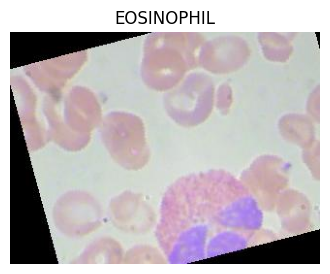

In [4]:
sample_cell_path, sample_cell_label = random.choice(train_ds_info.samples)
sample_cell_bgr = cv2.imread(sample_cell_path)
sample_cell_rgb = cv2.cvtColor(sample_cell_bgr, cv2.COLOR_BGR2RGB)

print("Sample cell:", sample_cell_path)
print("Ground truth:", train_ds_info.classes[sample_cell_label])

plt.figure(figsize=(4, 4))
plt.imshow(sample_cell_rgb)
plt.title(train_ds_info.classes[sample_cell_label])
plt.axis("off")
plt.show()


## 5. Khai báo weights


In [5]:
RBC_WEIGHTS = PROJECT_ROOT / "saved_models" / "rbc_yolo" / "weights" / "best.pt"
WBC_WEIGHTS = PROJECT_ROOT / "saved_models" / "wbc_classifier_best.pth"

print("RBC_WEIGHTS:", RBC_WEIGHTS)
print("WBC_WEIGHTS:", WBC_WEIGHTS)


RBC_WEIGHTS: f:\py\XLAS\HeaWeb\saved_models\rbc_yolo\weights\best.pt
WBC_WEIGHTS: f:\py\XLAS\HeaWeb\saved_models\wbc_classifier_best.pth


## 6. Load WBC classifier


In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
wbc_model = None
wbc_class_names = train_ds_info.classes
classifier_img_size = 224

if WBC_WEIGHTS is not None and Path(WBC_WEIGHTS).exists():
    wbc_model, wbc_class_names, backbone, classifier_img_size = load_wbc_classifier(str(WBC_WEIGHTS), device=device)
    print("Loaded WBC classifier")
    print("Backbone:", backbone)
    print("Image size:", classifier_img_size)
    print("Classes:", wbc_class_names)
else:
    print("Chưa có WBC classifier weights. Hãy train classifier trước nếu muốn predict class thật.")


Loaded WBC classifier
Backbone: resnet18
Image size: 224
Classes: ['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']


## 7. Test classifier trên ảnh single-cell


In [7]:
if wbc_model is not None:
    pred = predict_class(wbc_model, sample_cell_bgr, wbc_class_names, device=device, img_size=classifier_img_size)
    print("Ground truth:", train_ds_info.classes[sample_cell_label])
    print("Prediction:", pred["label"])
    print("Score:", pred["score"])
else:
    print("B? qua v? ch?a load WBC classifier.")


Ground truth: EOSINOPHIL
Prediction: EOSINOPHIL
Score: 0.9669080376625061


## 8. Kiểm tra XML dataset-master là phần hỗ trợ RBC


In [8]:
xml_names = []
for xml_path in sorted(ANNOTATION_DIR.glob("*.xml")):
    root = ET.parse(xml_path).getroot()
    for obj in root.findall("object"):
        xml_names.append(obj.find("name").text)

counter = Counter(xml_names)
print(counter)
counter


Counter({'RBC': 3854})


Counter({'RBC': 3854})

## 9. Xem ảnh kính hiển vi đầy đủ


Sample microscope image: f:\py\XLAS\HeaWeb\dataset-master\dataset-master\JPEGImages\BloodImage_00048.jpg


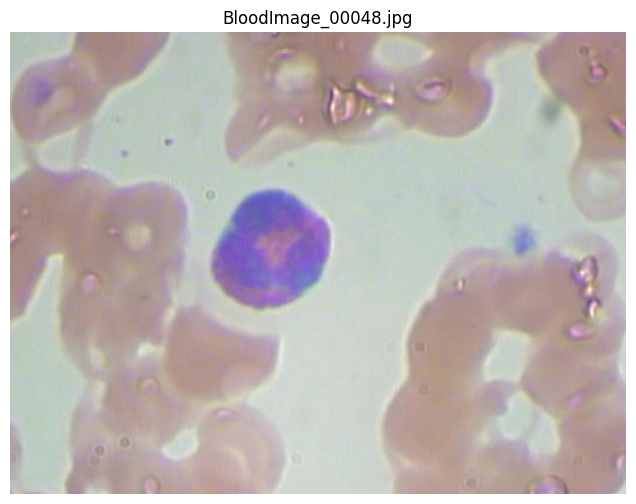

In [9]:
jpg_files = sorted(JPEG_DIR.glob("*.jpg"))
sample_image = random.choice(jpg_files)
img_bgr = cv2.imread(str(sample_image))
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

print("Sample microscope image:", sample_image)

plt.figure(figsize=(8, 6))
plt.imshow(img_rgb)
plt.title(sample_image.name)
plt.axis("off")
plt.show()


## 10. WBC proposal/crop tự động từ ảnh lớn


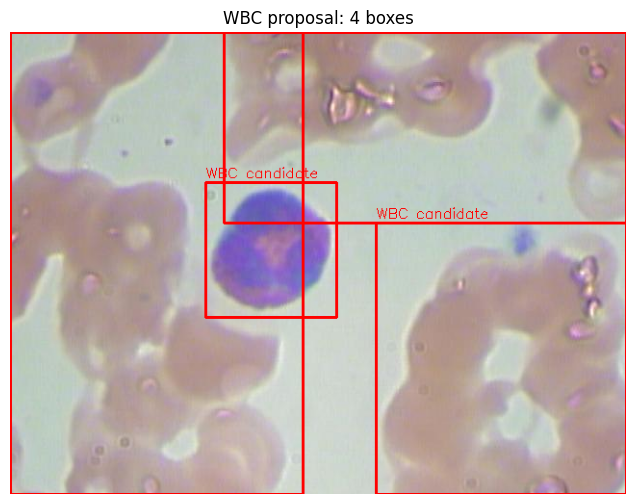

[[0, 0, 304, 480],
 [222, 0, 640, 198],
 [380, 198, 640, 480],
 [203, 156, 339, 296]]

In [10]:
proposal = WBCProposal(min_area=500, max_candidates=18)
wbc_boxes = proposal.propose(img_bgr)

vis = img_bgr.copy()
for x1, y1, x2, y2 in wbc_boxes:
    cv2.rectangle(vis, (int(x1), int(y1)), (int(x2), int(y2)), (0, 0, 255), 2)
    cv2.putText(vis, "WBC candidate", (int(x1), max(0, int(y1)-5)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,0,255), 1)

plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.title(f"WBC proposal: {len(wbc_boxes)} boxes")
plt.axis("off")
plt.show()

wbc_boxes[:10]


## 11. Xem các crop WBC candidate


Number of crops: 4


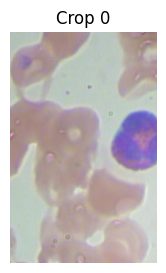

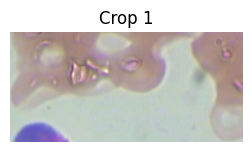

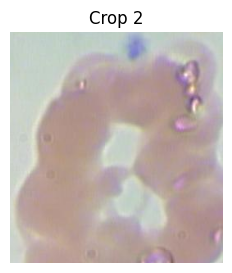

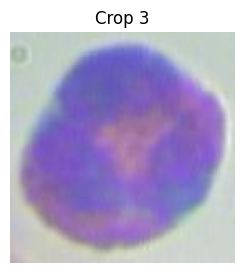

In [11]:
crops = proposal.crop_boxes(img_bgr, wbc_boxes)
print("Number of crops:", len(crops))

for i, crop in enumerate(crops[:6]):
    plt.figure(figsize=(3, 3))
    plt.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
    plt.title(f"Crop {i}")
    plt.axis("off")
    plt.show()


## 12. Classify crop candidate nếu đã có WBC classifier


In [12]:
if wbc_model is not None:
    for i, crop in enumerate(crops[:10]):
        pred = predict_class(wbc_model, crop, wbc_class_names, device=device, img_size=classifier_img_size)
        print(f"Crop {i}: {pred['label']} | score={pred['score']:.4f}")
else:
    print("B? qua v? ch?a load WBC classifier.")


Crop 0: EOSINOPHIL | score=1.0000
Crop 1: EOSINOPHIL | score=0.9663
Crop 2: EOSINOPHIL | score=1.0000
Crop 3: EOSINOPHIL | score=1.0000


## 13. Load RBC detector hỗ trợ


In [13]:
rbc_detector = None
rbc_boxes = []

if RBC_WEIGHTS is not None and Path(RBC_WEIGHTS).exists():
    rbc_detector = load_rbc_detector(model_type="yolov5", weights=str(RBC_WEIGHTS), classes=["RBC"], img_size=640, device=device)
    print("Loaded RBC detector")
else:
    print("Chưa có RBC detector weights. Có thể bỏ qua phần hỗ trợ RBC.")


Loaded RBC detector


## 14. Vẽ RBC boxes để kiểm tra



0: 480x640 8 RBCs, 169.9ms
Speed: 3.2ms preprocess, 169.9ms inference, 1.7ms postprocess per image at shape (1, 3, 480, 640)


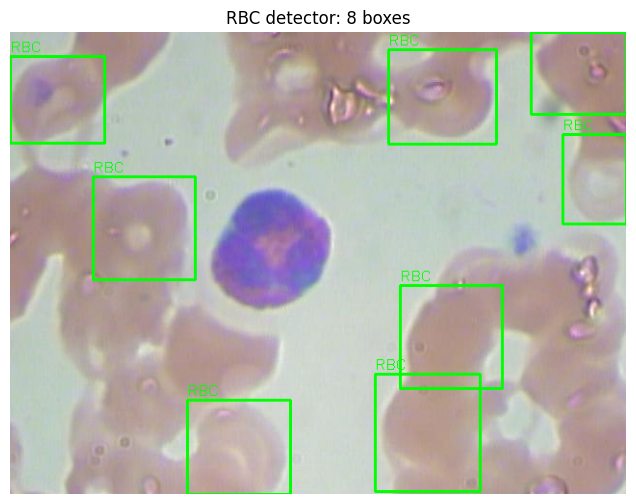

[[184.25457763671875, 382.68841552734375, 291.504150390625, 480.0],
 [393.09283447265625, 18.615966796875, 505.453369140625, 116.46865844726562],
 [0.0, 25.405437469482422, 98.02519989013672, 115.76899719238281],
 [541.4154052734375, 0.129852294921875, 640.0, 85.34413146972656],
 [405.966796875, 263.5799560546875, 511.6971435546875, 370.133056640625],
 [574.1670532226562, 106.40931701660156, 640.0, 199.28440856933594],
 [86.44351196289062, 150.13876342773438, 192.931884765625, 257.17620849609375],
 [379.82635498046875, 355.3980712890625, 488.82916259765625, 477.748779296875]]

In [14]:
rbc_boxes = []
if rbc_detector is not None:
    preds = rbc_detector.detect([img_bgr])[0]
    if preds is not None and len(preds) > 0:
        rbc_boxes = preds[:, 1:5].tolist()
    vis_rbc = draw_boxes(img_bgr, rbc_boxes, label="RBC", color=(0, 255, 0))
    plt.figure(figsize=(8, 6))
    plt.imshow(cv2.cvtColor(vis_rbc, cv2.COLOR_BGR2RGB))
    plt.title(f"RBC detector: {len(rbc_boxes)} boxes")
    plt.axis("off")
    plt.show()
else:
    print("B? qua v? ch?a c? RBC detector.")

rbc_boxes[:10]


## 15. WBC proposal sau khi loại vùng RBC


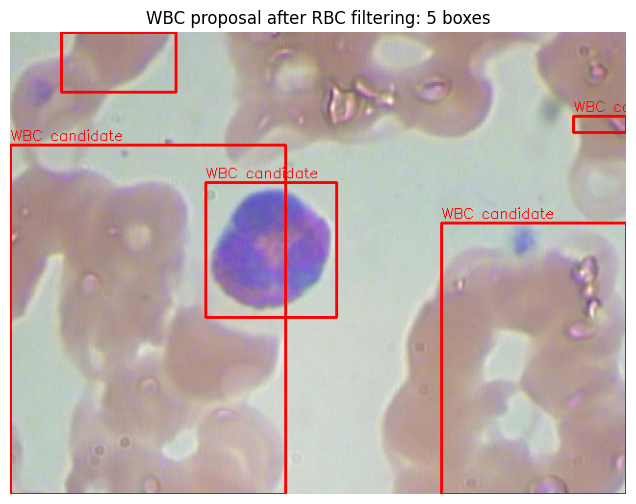

[[0, 117, 286, 480],
 [448, 198, 640, 480],
 [203, 156, 339, 296],
 [53, 0, 172, 62],
 [585, 87, 640, 104]]

In [15]:
filtered_wbc_boxes = proposal.propose(img_bgr, exclude_boxes=rbc_boxes)

vis_filtered = img_bgr.copy()
for x1, y1, x2, y2 in filtered_wbc_boxes:
    cv2.rectangle(vis_filtered, (int(x1), int(y1)), (int(x2), int(y2)), (0, 0, 255), 2)
    cv2.putText(vis_filtered, "WBC candidate", (int(x1), max(0, int(y1)-5)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,0,255), 1)

plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(vis_filtered, cv2.COLOR_BGR2RGB))
plt.title(f"WBC proposal after RBC filtering: {len(filtered_wbc_boxes)} boxes")
plt.axis("off")
plt.show()

filtered_wbc_boxes[:10]


## 16. Pipeline end-to-end



0: 480x640 8 RBCs, 137.7ms
Speed: 2.8ms preprocess, 137.7ms inference, 1.7ms postprocess per image at shape (1, 3, 480, 640)


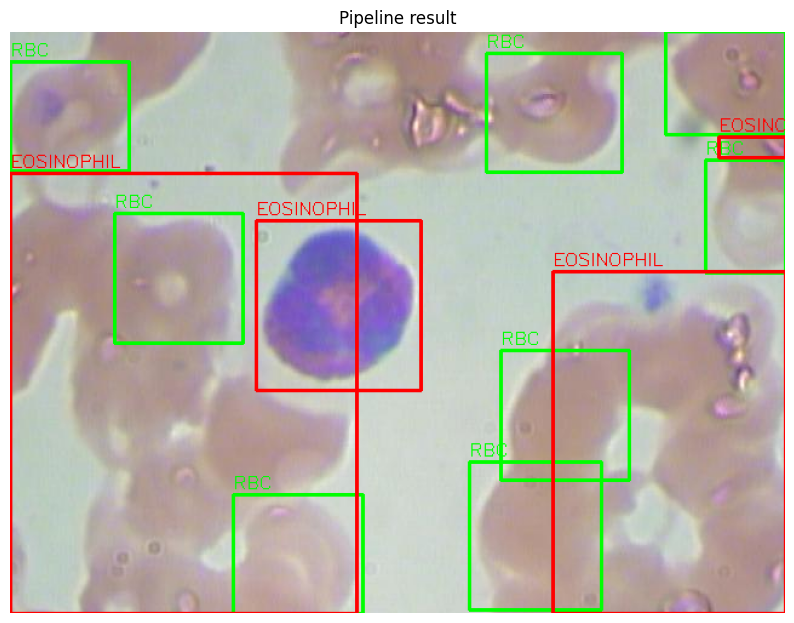

RBC boxes: 8
WBC boxes: 4
WBC predictions: [{'label': 'EOSINOPHIL', 'score': 1.0, 'probs': [1.0, 9.482964814875455e-14, 5.677212588928171e-10, 2.8631530923917126e-08], 'class_index': 0}, {'label': 'EOSINOPHIL', 'score': 0.9999983310699463, 'probs': [0.9999983310699463, 6.436049609925831e-13, 1.706753778307757e-07, 1.5887869722064352e-06], 'class_index': 0}, {'label': 'EOSINOPHIL', 'score': 0.9999997615814209, 'probs': [0.9999997615814209, 4.7934021310316934e-17, 2.0292580416025885e-07, 1.4568902500953297e-23], 'class_index': 0}, {'label': 'EOSINOPHIL', 'score': 1.0, 'probs': [1.0, 2.8288325458133978e-14, 1.3356930839147907e-10, 3.698826489539897e-08], 'class_index': 0}]


In [16]:
pipeline = CellPipeline(
    rbc_detector=rbc_detector,
    wbc_classifier=wbc_model,
    wbc_class_names=wbc_class_names,
    img_size=classifier_img_size,
    device=device,
)

result = pipeline.run(str(sample_image))
vis = pipeline.draw_result(result)

plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.title("Pipeline result")
plt.axis("off")
plt.show()

print("RBC boxes:", len(result["rbc_boxes"]))
print("WBC boxes:", len(result["wbc_boxes"]))
print("WBC predictions:", result["wbc_predictions"])


## 17. Kiểm tra model WBC đã train


In [ ]:
WBC_WEIGHTS = PROJECT_ROOT / "saved_models" / "wbc_classifier_best.pth"

if WBC_WEIGHTS.exists():
    print("Đã có WBC classifier weights:", WBC_WEIGHTS)
else:
    print("Chưa có WBC classifier weights.")
    print("Hãy train theo bước trong README trước, rồi quay lại notebook để test.")


## 18. Kiểm tra RBC detector hỗ trợ đã train


In [ ]:
RBC_WEIGHTS = PROJECT_ROOT / "saved_models" / "rbc_yolo" / "weights" / "best.pt"

if RBC_WEIGHTS.exists():
    print("Đã có RBC detector weights:", RBC_WEIGHTS)
else:
    print("Chưa có RBC detector weights.")
    print("Nếu muốn dùng RBC hỗ trợ trong pipeline, hãy train theo bước trong README trước.")


[INFO] Saved converted annotations to f:\py\XLAS\HeaWeb\dataset-master\dataset-master\YOLO_labels\annotations_converted.csv
class_id
0    3854
Name: count, dtype: int64


CalledProcessError: Command '['c:\\Users\\Admin\\AppData\\Local\\Programs\\Python\\Python313\\python.exe', '-m', 'src.train', '--task', 'detection', '--model', 'yolov5', '--img_dir', 'f:\\py\\XLAS\\HeaWeb\\dataset-master\\dataset-master\\JPEGImages', '--ann_file', 'f:\\py\\XLAS\\HeaWeb\\dataset-master\\dataset-master\\YOLO_labels\\annotations_converted.csv', '--classes', 'RBC', '--epochs', '20', '--batch_size', '4', '--img_size', '640', '--save_dir', 'f:\\py\\XLAS\\HeaWeb\\saved_models']' returned non-zero exit status 1.